# Customer Profitability Analysis

### Objective

This notebook evaluates customer-level financial contribution by
aggregating transaction-level sales, profit, discounts, orders, and
profit margins.

The analysis focuses on identifying high-value customers, high-revenue
but low-margin customers, loss-making customers, and customer-level
profit concentration.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the EDA dataset

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = "../data/processed/apl_logistics_eda.csv"

df = pd.read_csv(
    DATA_PATH,
    encoding="latin1"
)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 180,519
Columns: 42


In [3]:
# Validate customer identifiers

customer_id_check = (
    df["Customer Id"] == df["Order Customer Id"]
)

print("Matching customer IDs:",
      customer_id_check.sum())

print("Non-matching customer IDs:",
      (~customer_id_check).sum())

Matching customer IDs: 180519
Non-matching customer IDs: 0


In [4]:
#. Build the customer level dataset

customer_profitability = (
    df.groupby("Customer Id")
      .agg(
          Customer_Segment=("Customer Segment", "first"),
          Customer_Country=("Customer Country", "first"),
          Customer_Market=("Market", "first"),
          Orders=("Order Customer Id", "count"),
          Units=("Order Item Quantity", "sum"),
          Sales=("Sales", "sum"),
          Profit=("Order Profit Per Order", "sum"),
          Discount=("Order Item Discount", "sum"),
          Avg_Discount_Rate=("Order Item Discount Rate", "mean"),
          Avg_Order_Value=("Sales", "mean"),
          Late_Delivery_Rate=("Late_delivery_risk", "mean")
      )
      .reset_index()
)

In [6]:
# Calculate customer margin

customer_profitability["Profit_Margin"] = (
    customer_profitability["Profit"] /
    customer_profitability["Sales"]
)

print(
    "Invalid customer margins:",
    (~np.isfinite(customer_profitability["Profit_Margin"])).sum()
)

Invalid customer margins: 0


In [7]:
# Customer value index
# Customer Value Index (%) = Customer Profit / Total Net Profit × 100

total_net_profit = customer_profitability["Profit"].sum()

customer_profitability["Customer_Value_Index"] = (
    customer_profitability["Profit"] /
    total_net_profit *
    100
)

In [8]:
# Basic customer statistics

customer_profitability.describe()

,Customer Id,Orders,Units,Sales,Profit,Discount,Avg_Discount_Rate,Avg_Order_Value,Late_Delivery_Rate,Profit_Margin,Customer_Value_Index
count,"20,652.00","20,652.00","20,652.00","20,652.00","20,652.00","20,652.00","20,652.00","20,652.00","20,652.00","20,652.00","20,652.00"
mean,"10,400.29",8.74,18.60,"1,781.17",192.08,180.63,0.10,238.35,0.55,0.11,0.00
std,"5,993.11",8.38,19.18,"1,677.33",389.13,177.83,0.05,215.41,0.38,0.30,0.01
min,1.00,1.00,1.00,11.29,"-3,868.56",0.00,0.00,11.29,0.00,-2.67,-0.10
25%,"5,208.75",1.00,1.00,293.04,5.43,22.60,0.08,166.71,0.19,0.04,0.00
50%,"10,407.50",7.00,14.00,"1,499.82",109.83,133.15,0.10,204.48,0.58,0.17,0.00
75%,"15,594.25",15.00,32.00,"2,915.88",397.97,295.19,0.12,249.26,1.00,0.27,0.01
max,"20,757.00",47.00,114.00,"10,524.17","2,441.97","1,203.63",0.25,"1,500.00",1.00,0.50,0.06


In [9]:
print(
    f"Unique customers: "
    f"{customer_profitability['Customer Id'].nunique():,}"
)

Unique customers: 20,652


In [10]:
# Top customers by profit

top_profit_customers = (
    customer_profitability
    .sort_values("Profit", ascending=False)
    .head(20)
)

top_profit_customers[
    [
        "Customer Id",
        "Customer_Segment",
        "Customer_Country",
        "Orders",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount",
        "Customer_Value_Index"
    ]
]

,Customer Id,Customer_Segment,Customer_Country,Orders,Sales,Profit,Profit_Margin,Discount,Customer_Value_Index
2612,2641,Consumer,EE. UU.,43,"9,130.92","2,441.97",0.27,909.29,0.06
1636,1657,Consumer,Puerto Rico,42,"9,223.71","2,196.92",0.24,"1,058.49",0.06
9755,9833,Consumer,Puerto Rico,24,"6,059.38","1,938.39",0.32,672.92,0.05
2597,2626,Consumer,EE. UU.,27,"6,274.36","1,928.57",0.31,796.54,0.05
4958,5004,Home Office,EE. UU.,45,"8,164.70","1,917.99",0.23,665.35,0.05
3697,3735,Corporate,EE. UU.,27,"6,019.33","1,906.36",0.32,486.92,0.05
741,749,Consumer,Puerto Rico,38,"7,649.38","1,855.15",0.24,695.98,0.05
5509,5560,Corporate,Puerto Rico,29,"6,528.21","1,831.46",0.28,409.62,0.05
10875,10967,Consumer,Puerto Rico,27,"5,734.41","1,822.33",0.32,552.76,0.05
5007,5053,Corporate,Puerto Rico,33,"7,411.32","1,813.34",0.24,714.64,0.05


In [11]:
# Top customers by revenue

top_revenue_customers = (
    customer_profitability
    .sort_values("Sales", ascending=False)
    .head(20)
)

top_revenue_customers[
    [
        "Customer Id",
        "Customer_Segment",
        "Orders",
        "Sales",
        "Profit",
        "Profit_Margin"
    ]
]

,Customer Id,Customer_Segment,Orders,Sales,Profit,Profit_Margin
782,791,Corporate,43,"10,524.17",-866.38,-0.08
9295,9371,Consumer,44,"9,299.03","1,346.58",0.14
8694,8766,Corporate,38,"9,296.14","1,495.16",0.16
1636,1657,Consumer,42,"9,223.71","2,196.92",0.24
2612,2641,Consumer,43,"9,130.92","2,441.97",0.27
1271,1288,Home Office,42,"9,019.11",403.11,0.04
3672,3710,Consumer,42,"9,019.10","1,055.13",0.12
4209,4249,Consumer,39,"8,918.85",439.71,0.05
5603,5654,Home Office,47,"8,904.95","1,045.36",0.12
5573,5624,Consumer,38,"8,761.98","1,178.15",0.13


In [12]:
# High revenue / low margin customers

sales_median = customer_profitability["Sales"].median()
margin_median = customer_profitability["Profit_Margin"].median()

print(f"Customer sales median: {sales_median:,.2f}")
print(f"Customer profit margin median: {margin_median:.2%}")

Customer sales median: 1,499.82
Customer profit margin median: 16.70%


In [13]:
high_revenue_low_margin = customer_profitability[
    (customer_profitability["Sales"] >= sales_median) &
    (customer_profitability["Profit_Margin"] < margin_median)
].copy()

In [14]:
high_revenue_low_margin = (
    high_revenue_low_margin
    .sort_values("Sales", ascending=False)
)

In [15]:
high_revenue_low_margin[
    [
        "Customer Id",
        "Customer_Segment",
        "Orders",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount",
        "Avg_Discount_Rate"
    ]
].head(20)

,Customer Id,Customer_Segment,Orders,Sales,Profit,Profit_Margin,Discount,Avg_Discount_Rate
782,791,Corporate,43,"10,524.17",-866.38,-0.08,"1,087.57",0.10
9295,9371,Consumer,44,"9,299.03","1,346.58",0.14,"1,076.36",0.10
8694,8766,Corporate,38,"9,296.14","1,495.16",0.16,895.18,0.10
1271,1288,Home Office,42,"9,019.11",403.11,0.04,"1,150.11",0.11
3672,3710,Consumer,42,"9,019.10","1,055.13",0.12,906.97,0.09
4209,4249,Consumer,39,"8,918.85",439.71,0.05,720.70,0.09
5603,5654,Home Office,47,"8,904.95","1,045.36",0.12,986.21,0.10
5573,5624,Consumer,38,"8,761.98","1,178.15",0.13,956.41,0.12
5664,5715,Corporate,44,"8,595.13",-177.45,-0.02,714.04,0.09
1446,1464,Consumer,42,"8,409.22",797.25,0.09,862.96,0.10


In [16]:
# Loss making customers

loss_making_customers = customer_profitability[
    customer_profitability["Profit"] < 0
].copy()

print(
    f"Loss-making customers: "
    f"{len(loss_making_customers):,}"
)

Loss-making customers: 4,069


In [17]:
loss_making_customers[
    [
        "Customer Id",
        "Customer_Segment",
        "Customer_Country",
        "Orders",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Discount"
    ]
].sort_values("Profit").head(20)

,Customer Id,Customer_Segment,Customer_Country,Orders,Sales,Profit,Profit_Margin,Discount
1410,1428,Consumer,EE. UU.,13,"3,883.67","-3,868.56",-1.00,252.64
13980,14086,Home Office,EE. UU.,1,"1,500.00","-3,442.50",-2.29,150.00
18003,18109,Corporate,Puerto Rico,1,"1,500.00","-3,366.00",-2.24,180.00
14207,14313,Consumer,Puerto Rico,1,"1,500.00","-3,000.00",-2.00,300.00
17955,18061,Consumer,EE. UU.,1,"1,500.00","-2,592.00",-1.73,60.00
14007,14113,Consumer,Puerto Rico,1,"1,500.00","-2,550.00",-1.70,0.00
13984,14090,Corporate,EE. UU.,1,"1,500.00","-2,351.25",-1.57,75.00
14292,14398,Home Office,Puerto Rico,1,"1,500.00","-2,328.00",-1.55,45.00
14200,14306,Home Office,EE. UU.,1,"1,500.00","-2,280.00",-1.52,75.00
14130,14236,Consumer,EE. UU.,1,"1,500.00","-2,255.25",-1.50,45.00


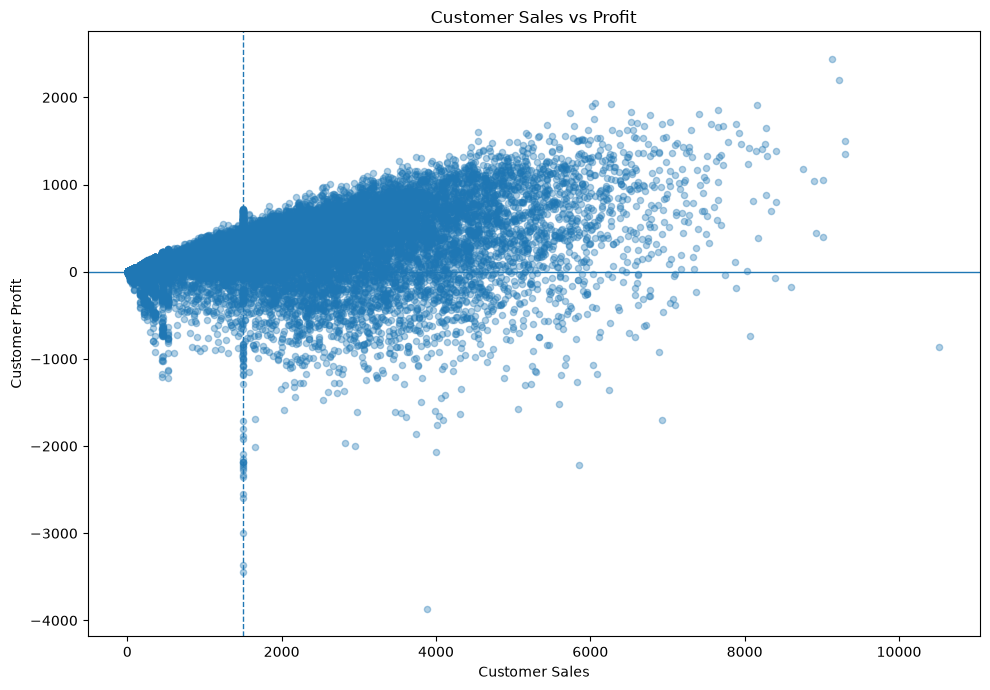

In [18]:
# Customer profitability matrix

plt.figure(figsize=(10, 7))

plt.scatter(
    customer_profitability["Sales"],
    customer_profitability["Profit"],
    alpha=0.35,
    s=20
)

plt.axhline(0, linewidth=1)

plt.axvline(
    sales_median,
    linestyle="--",
    linewidth=1
)

plt.title("Customer Sales vs Profit")
plt.xlabel("Customer Sales")
plt.ylabel("Customer Profit")

plt.tight_layout()
plt.show()

In [ ]:
"""                   HIGH PROFIT
                       ↑
        Growth         |       High-value
        opportunity    |       customers
                       |
LOW SALES -------------+------------- HIGH SALES
                       |
        Low-value      |       Revenue-heavy
        customers      |       / margin risk
                       |
                       ↓
                  LOW PROFIT """

In [19]:
# Create customer value segments

customer_profitability["Customer_Value_Segment"] = np.select(
    [
        (customer_profitability["Sales"] >= sales_median) &
        (customer_profitability["Profit"] >= 0),

        (customer_profitability["Sales"] >= sales_median) &
        (customer_profitability["Profit"] < 0),

        (customer_profitability["Sales"] < sales_median) &
        (customer_profitability["Profit"] >= 0),

        (customer_profitability["Sales"] < sales_median) &
        (customer_profitability["Profit"] < 0)
    ],
    [
        "High Revenue / Positive Profit",
        "High Revenue / Negative Profit",
        "Lower Revenue / Positive Profit",
        "Lower Revenue / Negative Profit"
    ],
    default="Unclassified"
)

In [20]:
customer_profitability[
    "Customer_Value_Segment"
].value_counts()

Customer_Value_Segment
Lower Revenue / Positive Profit    8324
High Revenue / Positive Profit     8259
High Revenue / Negative Profit     2067
Lower Revenue / Negative Profit    2002
Name: count, dtype: int64

In [21]:
# Segment financial contribution

customer_segment_summary = (
    customer_profitability
    .groupby("Customer_Value_Segment")
    .agg(
        Customers=("Customer Id", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Orders", "sum"),
        Discount=("Discount", "sum")
    )
    .reset_index()
)

In [22]:
customer_segment_summary["Profit_Margin"] = (
    customer_segment_summary["Profit"] /
    customer_segment_summary["Sales"]
)

customer_segment_summary["Sales_Share"] = (
    customer_segment_summary["Sales"] /
    customer_segment_summary["Sales"].sum()
)

customer_segment_summary["Profit_Share"] = (
    customer_segment_summary["Profit"] /
    customer_segment_summary["Profit"].sum()
)

In [23]:
# Customer profit concentration

customer_profit_sorted = (
    customer_profitability
    .sort_values("Profit", ascending=False)
    .reset_index(drop=True)
)

In [24]:
customer_profit_sorted["Cumulative_Profit"] = (
    customer_profit_sorted["Profit"].cumsum()
)

In [26]:
customer_profit_sorted["Cumulative_Profit_Share"] = (
    customer_profit_sorted["Cumulative_Profit"] /
    customer_profitability["Profit"].sum()
)

customer_profit_sorted.head(20)

,Customer Id,Customer_Segment,Customer_Country,Customer_Market,Orders,Units,Sales,Profit,Discount,Avg_Discount_Rate,Avg_Order_Value,Late_Delivery_Rate,Profit_Margin,Customer_Value_Index,Customer_Value_Segment,Cumulative_Profit,Cumulative_Profit_Share
0,2641,Consumer,EE. UU.,USCA,43,90,"9,130.92","2,441.97",909.29,0.09,212.35,0.51,0.27,0.06,High Revenue / Positive Profit,"2,441.97",0.00
1,1657,Consumer,Puerto Rico,USCA,42,111,"9,223.71","2,196.92","1,058.49",0.11,219.61,0.67,0.24,0.06,High Revenue / Positive Profit,"4,638.89",0.00
2,9833,Consumer,Puerto Rico,Europe,24,48,"6,059.38","1,938.39",672.92,0.11,252.47,0.54,0.32,0.05,High Revenue / Positive Profit,"6,577.28",0.00
3,2626,Consumer,EE. UU.,Africa,27,55,"6,274.36","1,928.57",796.54,0.12,232.38,0.41,0.31,0.05,High Revenue / Positive Profit,"8,505.85",0.00
4,5004,Home Office,EE. UU.,LATAM,45,114,"8,164.70","1,917.99",665.35,0.09,181.44,0.38,0.23,0.05,High Revenue / Positive Profit,"10,423.84",0.00
5,3735,Corporate,EE. UU.,USCA,27,61,"6,019.33","1,906.36",486.92,0.08,222.94,0.48,0.32,0.05,High Revenue / Positive Profit,"12,330.20",0.00
6,749,Consumer,Puerto Rico,Africa,38,64,"7,649.38","1,855.15",695.98,0.09,201.30,0.61,0.24,0.05,High Revenue / Positive Profit,"14,185.35",0.00
7,5560,Corporate,Puerto Rico,LATAM,29,74,"6,528.21","1,831.46",409.62,0.07,225.11,0.55,0.28,0.05,High Revenue / Positive Profit,"16,016.81",0.00
8,10967,Consumer,Puerto Rico,Pacific Asia,27,64,"5,734.41","1,822.33",552.76,0.09,212.39,0.59,0.32,0.05,High Revenue / Positive Profit,"17,839.14",0.00
9,5053,Corporate,Puerto Rico,Europe,33,67,"7,411.32","1,813.34",714.64,0.09,224.59,0.64,0.24,0.05,High Revenue / Positive Profit,"19,652.48",0.00


In [27]:
# Save the customer dataset

customer_path = "../data/processed/customer_profitability.csv"

customer_profitability.to_csv(
    customer_path,
    index=False
)

print(f"Saved: {customer_path}")
print(f"Customers: {len(customer_profitability):,}")
print(f"Columns: {len(customer_profitability.columns)}")

Saved: ../data/processed/customer_profitability.csv
Customers: 20,652
Columns: 15


## Step 3B: Customer Contribution Analysis

In [55]:
# Customer value segment financial summary

customer_segment_summary = (
    customer_profitability
    .groupby("Customer_Value_Segment")
    .agg(
        Customers=("Customer Id", "nunique"),
        Orders=("Orders", "sum"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Discount=("Discount", "sum")
    )
    .reset_index()
)

# Overall margin
customer_segment_summary["Profit_Margin"] = (
    customer_segment_summary["Profit"] /
    customer_segment_summary["Sales"]
)

# Sales contribution
customer_segment_summary["Sales_Share"] = (
    customer_segment_summary["Sales"] /
    customer_segment_summary["Sales"].sum()
)

# Positive profit and total loss pools
positive_profit_total = customer_profitability.loc[
    customer_profitability["Profit"] > 0,
    "Profit"
].sum()

negative_profit_total = -customer_profitability.loc[
    customer_profitability["Profit"] < 0,
    "Profit"
].sum()

# Contribution to positive profit
customer_segment_summary["Positive_Profit_Contribution"] = np.where(
    customer_segment_summary["Profit"] > 0,
    customer_segment_summary["Profit"] / positive_profit_total,
    np.nan
)

# Contribution to total losses
customer_segment_summary["Loss_Contribution"] = np.where(
    customer_segment_summary["Profit"] < 0,
    -customer_segment_summary["Profit"] / negative_profit_total,
    np.nan
)

customer_segment_summary

,Customer_Value_Segment,Customers,Orders,Sales,Profit,Discount,Profit_Margin,Sales_Share,Positive_Profit_Contribution,Loss_Contribution
0,High Revenue / Negative Profit,2067,30761,"6,280,838.78","-792,621.56","633,953.70",-0.13,0.17,NaN,0.73
1,High Revenue / Positive Profit,8259,128722,"26,354,542.77","4,275,428.21","2,677,414.31",0.16,0.72,0.85,NaN
2,Lower Revenue / Negative Profit,2002,4203,"833,240.56","-287,678.16","84,003.22",-0.35,0.02,NaN,0.27
3,Lower Revenue / Positive Profit,8324,16833,"3,316,112.20","771,774.48","335,007.17",0.23,0.09,0.15,NaN


In [57]:
# Customer segment summary for presentation

customer_segment_display = customer_segment_summary.copy()

# Convert ratios to percentages
customer_segment_display["Profit_Margin"] = (
    customer_segment_display["Profit_Margin"] * 100
).round(2)

customer_segment_display["Sales_Share"] = (
    customer_segment_display["Sales_Share"] * 100
).round(2)

customer_segment_display["Positive_Profit_Contribution"] = (
    customer_segment_display["Positive_Profit_Contribution"] * 100
).round(2)

customer_segment_display["Loss_Contribution"] = (
    customer_segment_display["Loss_Contribution"] * 100
).round(2)

# Replace non-applicable NaN values with 0
customer_segment_display[
    [
        "Positive_Profit_Contribution",
        "Loss_Contribution"
    ]
] = customer_segment_display[
    [
        "Positive_Profit_Contribution",
        "Loss_Contribution"
    ]
].fillna(0)

customer_segment_display

,Customer_Value_Segment,Customers,Orders,Sales,Profit,Discount,Profit_Margin,Sales_Share,Positive_Profit_Contribution,Loss_Contribution
0,High Revenue / Negative Profit,2067,30761,"6,280,838.78","-792,621.56","633,953.70",-12.62,17.07,0.00,73.37
1,High Revenue / Positive Profit,8259,128722,"26,354,542.77","4,275,428.21","2,677,414.31",16.22,71.65,84.71,0.00
2,Lower Revenue / Negative Profit,2002,4203,"833,240.56","-287,678.16","84,003.22",-34.53,2.27,0.00,26.63
3,Lower Revenue / Positive Profit,8324,16833,"3,316,112.20","771,774.48","335,007.17",23.27,9.01,15.29,0.00


In [59]:
# Compare revenue and profit rankings

customer_profitability["Sales_Rank"] = (
    customer_profitability["Sales"]
    .rank(method="min", ascending=False)
)

customer_profitability["Profit_Rank"] = (
    customer_profitability["Profit"]
    .rank(method="min", ascending=False)
)

In [60]:
customer_profitability["Rank_Gap"] = (
    customer_profitability["Sales_Rank"] -
    customer_profitability["Profit_Rank"]
)

In [61]:
customer_profitability[
    [
        "Customer Id",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Sales_Rank",
        "Profit_Rank",
        "Rank_Gap"
    ]
].sort_values(
    "Rank_Gap",
    ascending=False
).head(20)

,Customer Id,Sales,Profit,Profit_Margin,Sales_Rank,Profit_Rank,Rank_Gap
14005,14111,"1,500.00",720.30,0.48,"9,871.00","1,880.00","7,991.00"
14133,14239,"1,500.00",720.00,0.48,"9,871.00","1,881.00","7,990.00"
14115,14221,"1,500.00",720.00,0.48,"9,871.00","1,881.00","7,990.00"
14148,14254,"1,500.00",712.95,0.48,"9,871.00","1,916.00","7,955.00"
13983,14089,"1,500.00",708.75,0.47,"9,871.00","1,950.00","7,921.00"
14149,14255,"1,500.00",705.60,0.47,"9,871.00","1,972.00","7,899.00"
14131,14237,"1,500.00",705.60,0.47,"9,871.00","1,972.00","7,899.00"
13989,14095,"1,500.00",705.00,0.47,"9,871.00","1,980.00","7,891.00"
14256,14362,"1,500.00",698.40,0.47,"9,871.00","2,019.00","7,852.00"
14004,14110,"1,500.00",698.40,0.47,"9,871.00","2,019.00","7,852.00"


In [62]:
customer_profitability[
    [
        "Customer Id",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Sales_Rank",
        "Profit_Rank",
        "Rank_Gap"
    ]
].sort_values(
    "Rank_Gap"
).head(20)

,Customer Id,Sales,Profit,Profit_Margin,Sales_Rank,Profit_Rank,Rank_Gap
12080,12180,"6,924.48","-1,703.68",-0.25,118.00,"20,624.00","-20,506.00"
782,791,"10,524.17",-866.38,-0.08,1.00,"20,445.00","-20,444.00"
8247,8314,"6,891.15",-917.80,-0.13,122.00,"20,471.00","-20,349.00"
9850,9928,"6,241.10","-1,360.16",-0.22,265.00,"20,603.00","-20,338.00"
12326,12431,"8,073.15",-737.10,-0.09,25.00,"20,323.00","-20,298.00"
9662,9740,"6,089.23","-1,167.71",-0.19,310.00,"20,573.00","-20,263.00"
625,633,"5,848.46","-2,211.58",-0.38,408.00,"20,641.00","-20,233.00"
3762,3800,"6,033.55","-1,066.24",-0.18,324.00,"20,540.00","-20,216.00"
5555,5606,"5,829.37","-1,270.48",-0.22,419.00,"20,590.00","-20,171.00"
1820,1844,"6,579.39",-749.48,-0.11,184.00,"20,345.00","-20,161.00"


In [63]:
# High revenue/ low margin customer analysis

high_revenue_low_margin = customer_profitability[
    (customer_profitability["Sales"] >= sales_median) &
    (customer_profitability["Profit_Margin"] < margin_median)
].copy()

In [64]:
high_revenue_low_margin_summary = pd.DataFrame({
    "Customers": [len(high_revenue_low_margin)],
    "Sales": [high_revenue_low_margin["Sales"].sum()],
    "Profit": [high_revenue_low_margin["Profit"].sum()],
    "Discount": [high_revenue_low_margin["Discount"].sum()]
})

high_revenue_low_margin_summary["Profit_Margin"] = (
    high_revenue_low_margin_summary["Profit"] /
    high_revenue_low_margin_summary["Sales"]
)

high_revenue_low_margin_summary

,Customers,Sales,Profit,Discount,Profit_Margin
0,6043,"19,743,454.60","488,999.64","2,012,790.51",0.02


In [65]:
high_revenue_low_margin_summary["Sales_Share"] = (
    high_revenue_low_margin_summary["Sales"].iloc[0] /
    customer_profitability["Sales"].sum()
)

high_revenue_low_margin_summary["Profit_Share"] = (
    high_revenue_low_margin_summary["Profit"].iloc[0] /
    customer_profitability["Profit"].sum()
)

high_revenue_low_margin_summary

,Customers,Sales,Profit,Discount,Profit_Margin,Sales_Share,Profit_Share
0,6043,"19,743,454.60","488,999.64","2,012,790.51",0.02,0.54,0.12


In [66]:
# Loss making customer exposure

loss_customer_summary = pd.DataFrame({
    "Customers": [
        len(loss_making_customers)
    ],
    "Sales": [
        loss_making_customers["Sales"].sum()
    ],
    "Profit": [
        loss_making_customers["Profit"].sum()
    ],
    "Discount": [
        loss_making_customers["Discount"].sum()
    ]
})

loss_customer_summary["Sales_Share"] = (
    loss_customer_summary["Sales"] /
    customer_profitability["Sales"].sum()
)

loss_customer_summary["Profit_Impact_Share"] = (
    loss_customer_summary["Profit"] /
    customer_profitability["Profit"].sum()
)

loss_customer_summary

,Customers,Sales,Profit,Discount,Sales_Share,Profit_Impact_Share
0,4069,"7,114,079.34","-1,080,299.72","717,956.92",0.19,-0.27


In [67]:
total_customer_losses = (
    -loss_making_customers["Profit"].sum()
)

print(
    f"Aggregate customer-level loss: "
    f"${total_customer_losses:,.2f}"
)

Aggregate customer-level loss: $1,080,299.72


In [68]:
# Customer profit concentration 

customer_profit_sorted

,Customer Id,Customer_Segment,Customer_Country,Customer_Market,Orders,Units,Sales,Profit,Discount,Avg_Discount_Rate,Avg_Order_Value,Late_Delivery_Rate,Profit_Margin,Customer_Value_Index,Customer_Value_Segment,Cumulative_Profit,Cumulative_Profit_Share
0,2641,Consumer,EE. UU.,USCA,43,90,"9,130.92","2,441.97",909.29,0.09,212.35,0.51,0.27,0.06,High Revenue / Positive Profit,"2,441.97",0.00
1,1657,Consumer,Puerto Rico,USCA,42,111,"9,223.71","2,196.92","1,058.49",0.11,219.61,0.67,0.24,0.06,High Revenue / Positive Profit,"4,638.89",0.00
2,9833,Consumer,Puerto Rico,Europe,24,48,"6,059.38","1,938.39",672.92,0.11,252.47,0.54,0.32,0.05,High Revenue / Positive Profit,"6,577.28",0.00
3,2626,Consumer,EE. UU.,Africa,27,55,"6,274.36","1,928.57",796.54,0.12,232.38,0.41,0.31,0.05,High Revenue / Positive Profit,"8,505.85",0.00
4,5004,Home Office,EE. UU.,LATAM,45,114,"8,164.70","1,917.99",665.35,0.09,181.44,0.38,0.23,0.05,High Revenue / Positive Profit,"10,423.84",0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20647,18061,Consumer,EE. UU.,Pacific Asia,1,1,"1,500.00","-2,592.00",60.00,0.04,"1,500.00",0.00,-1.73,-0.07,High Revenue / Negative Profit,"3,980,580.03",1.00
20648,14313,Consumer,Puerto Rico,Europe,1,1,"1,500.00","-3,000.00",300.00,0.20,"1,500.00",1.00,-2.00,-0.08,High Revenue / Negative Profit,"3,977,580.03",1.00
20649,18109,Corporate,Puerto Rico,Pacific Asia,1,1,"1,500.00","-3,366.00",180.00,0.12,"1,500.00",0.00,-2.24,-0.08,High Revenue / Negative Profit,"3,974,214.03",1.00
20650,14086,Home Office,EE. UU.,Europe,1,1,"1,500.00","-3,442.50",150.00,0.10,"1,500.00",1.00,-2.29,-0.09,High Revenue / Negative Profit,"3,970,771.53",1.00


In [69]:
# Calculate cumulative profit share more carefully 

positive_customer_profit = (
    customer_profitability[
        customer_profitability["Profit"] > 0
    ]
    .sort_values("Profit", ascending=False)
    .reset_index(drop=True)
)

positive_customer_profit["Cumulative_Profit"] = (
    positive_customer_profit["Profit"].cumsum()
)

total_positive_customer_profit = (
    positive_customer_profit["Profit"].sum()
)

positive_customer_profit["Cumulative_Profit_Share"] = (
    positive_customer_profit["Cumulative_Profit"] /
    total_positive_customer_profit
)

In [70]:
# Calculate the contribution of the top customer groups

concentration_results = []

for pct in [1, 5, 10, 20]:
    n = max(
        1,
        int(np.ceil(
            len(positive_customer_profit) * pct / 100
        ))
    )
    
    profit_share = (
        positive_customer_profit
        .head(n)["Profit"]
        .sum()
        / total_positive_customer_profit
    )
    
    concentration_results.append({
        "Customer Group": f"Top {pct}%",
        "Customers": n,
        "Positive Profit Share": profit_share
    })

concentration_df = pd.DataFrame(concentration_results)

concentration_df["Positive Profit Share"] = (
    concentration_df["Positive Profit Share"] * 100
).round(2)

concentration_df

,Customer Group,Customers,Positive Profit Share
0,Top 1%,166,4.81
1,Top 5%,827,18.89
2,Top 10%,1653,32.67
3,Top 20%,3306,53.81


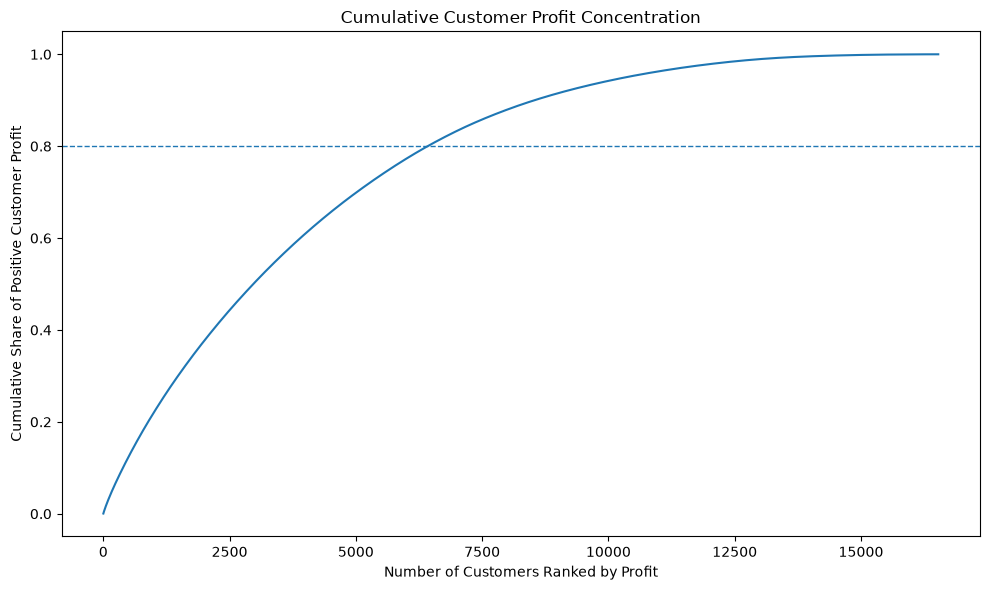

In [71]:
# Customer profit concentration chart 

plt.figure(figsize=(10, 6))

plt.plot(
    positive_customer_profit.index + 1,
    positive_customer_profit["Cumulative_Profit_Share"]
)

plt.axhline(
    0.80,
    linestyle="--",
    linewidth=1
)

plt.title("Cumulative Customer Profit Concentration")
plt.xlabel("Number of Customers Ranked by Profit")
plt.ylabel("Cumulative Share of Positive Customer Profit")

plt.tight_layout()
plt.show()

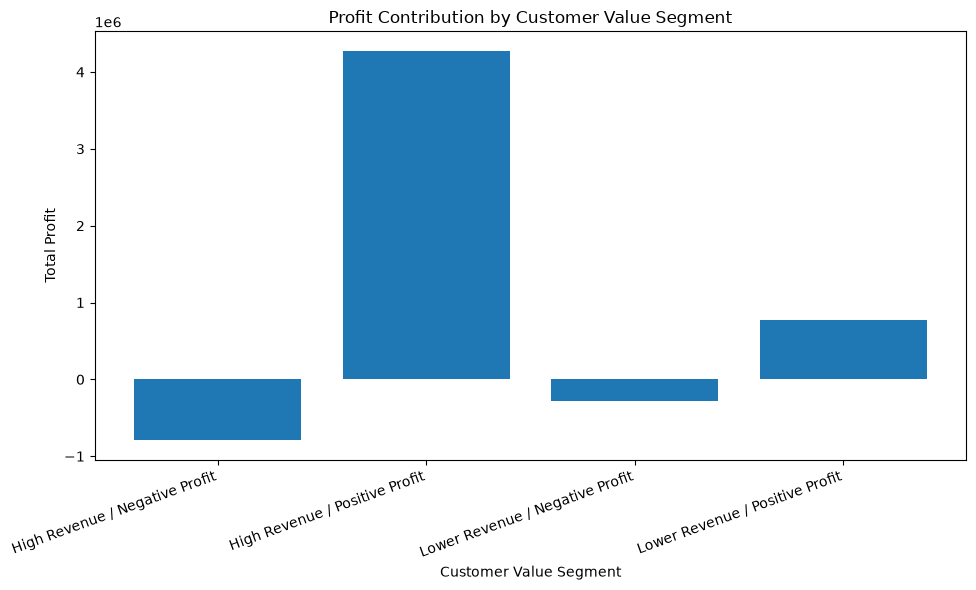

In [72]:
# Customer segment contribution chart 

plt.figure(figsize=(10, 6))

plt.bar(
    customer_segment_summary["Customer_Value_Segment"],
    customer_segment_summary["Profit"]
)

plt.title("Profit Contribution by Customer Value Segment")
plt.xlabel("Customer Value Segment")
plt.ylabel("Total Profit")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

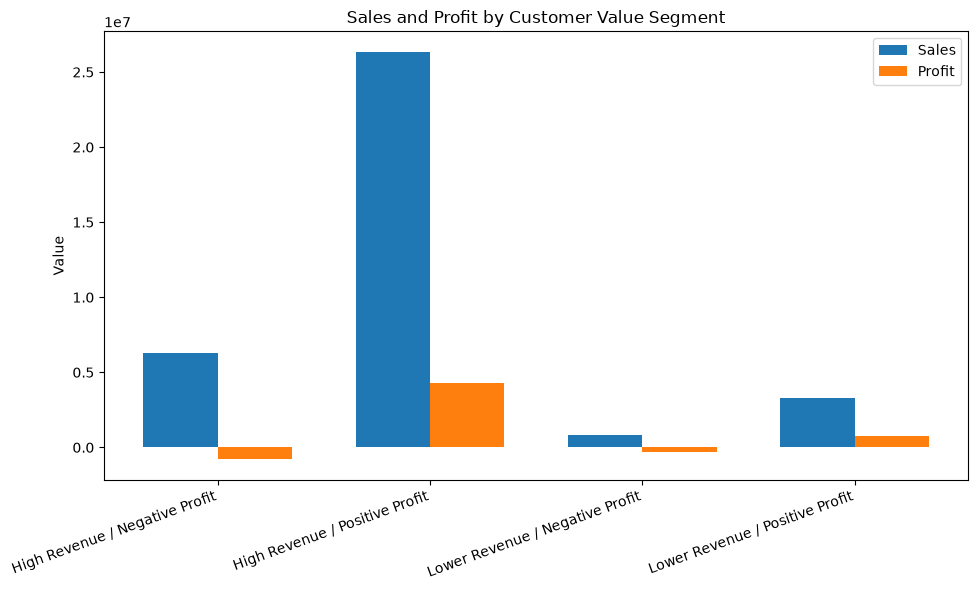

In [73]:
# Customer sales versus profit by segment 

x = np.arange(len(customer_segment_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width / 2,
    customer_segment_summary["Sales"],
    width,
    label="Sales"
)

ax.bar(
    x + width / 2,
    customer_segment_summary["Profit"],
    width,
    label="Profit"
)

ax.set_xticks(x)
ax.set_xticklabels(
    customer_segment_summary["Customer_Value_Segment"],
    rotation=20,
    ha="right"
)

ax.set_title("Sales and Profit by Customer Value Segment")
ax.set_ylabel("Value")
ax.legend()

plt.tight_layout()
plt.show()

In [74]:
# Check customer level discount relationship

customer_discount_corr = (
    customer_profitability[
        [
            "Avg_Discount_Rate",
            "Profit_Margin"
        ]
    ]
    .corr()
)

customer_discount_corr

,Avg_Discount_Rate,Profit_Margin
Avg_Discount_Rate,1.00,-0.03
Profit_Margin,-0.03,1.00


In [46]:
# Save the final customer dataset

customer_profitability.to_csv(
    "../data/processed/customer_profitability.csv",
    index=False
)

print("Customer profitability dataset updated successfully.")

Customer profitability dataset updated successfully.


## Customer Segment Performance

This section compares profitability across the customer segments
provided in the original dataset.

In [75]:
# Aggregate financial performance by original customer segment

customer_type_summary = (
    customer_profitability
    .groupby("Customer_Segment")
    .agg(
        Customers=("Customer Id", "nunique"),
        Orders=("Orders", "sum"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Discount=("Discount", "sum")
    )
    .reset_index()
)

customer_type_summary["Profit_Margin"] = (
    customer_type_summary["Profit"] /
    customer_type_summary["Sales"]
)

customer_type_summary["Average_Order_Value"] = (
    customer_type_summary["Sales"] /
    customer_type_summary["Orders"]
)

customer_type_summary

,Customer_Segment,Customers,Orders,Sales,Profit,Discount,Profit_Margin,Average_Order_Value
0,Consumer,10695,93504,"19,095,789.79","2,073,487.67","1,931,535.70",0.11,204.22
1,Corporate,6239,54789,"11,168,406.63","1,202,574.96","1,137,770.70",0.11,203.84
2,Home Office,3718,32226,"6,520,537.89","690,840.34","661,072.00",0.11,202.34


### Add a new cell for loss-making customers by segment

In [76]:
# Count customers with negative aggregate profit by customer segment

loss_making_by_segment = (
    customer_profitability[
        customer_profitability["Profit"] < 0
    ]
    .groupby("Customer_Segment")
    .agg(
        Loss_Making_Customers=("Customer Id", "nunique"),
        Total_Loss=("Profit", "sum")
    )
    .reset_index()
)

loss_making_by_segment

,Customer_Segment,Loss_Making_Customers,Total_Loss
0,Consumer,2101,"-553,334.67"
1,Corporate,1217,"-327,217.98"
2,Home Office,751,"-199,747.07"


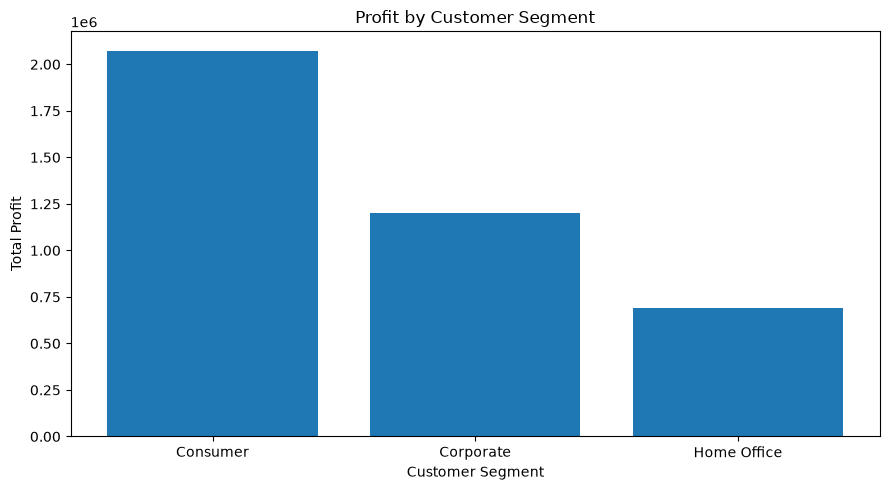

In [77]:
# Profit by original customer segment

plt.figure(figsize=(9, 5))

plt.bar(
    customer_type_summary["Customer_Segment"],
    customer_type_summary["Profit"]
)

plt.title("Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.show()

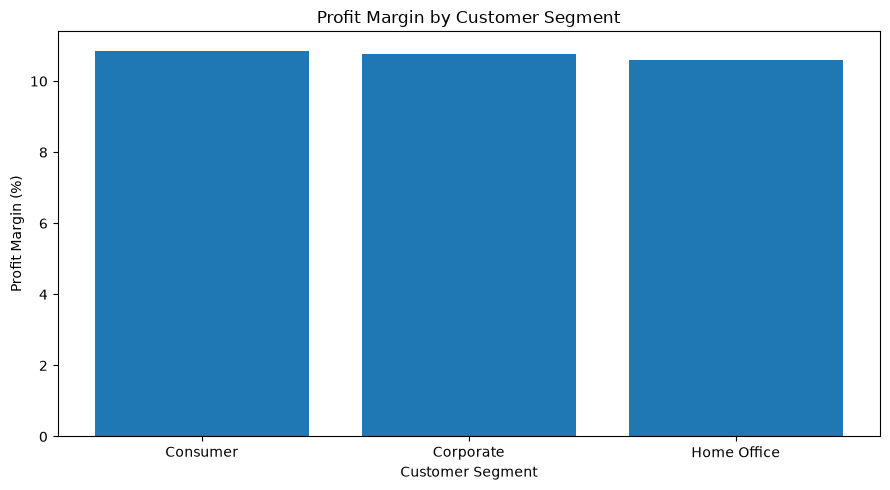

In [78]:
# Profit margin by customer segment

plt.figure(figsize=(9, 5))

plt.bar(
    customer_type_summary["Customer_Segment"],
    customer_type_summary["Profit_Margin"] * 100
)

plt.title("Profit Margin by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()
plt.show()

## Customer Profitability Findings

The customer-level analysis identifies substantial variation in
profitability across the customer base.

Customer profitability is evaluated using sales, aggregate profit,
profit margin, discount exposure, and customer contribution.

The analysis also distinguishes between high-revenue customers with
positive profitability and high-revenue customers with negative
profitability. This distinction is important because revenue volume
does not necessarily correspond to equivalent profit contribution.

The original customer segments are also compared to identify
differences in sales, profit, margin, order value, and loss-making
customer exposure.

The relationship between discounts and customer margins is treated as
a diagnostic relationship rather than evidence of causality. Further
discount-band analysis is conducted separately.